Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# MONAI 101 tutorial

In this tutorial, we will introduce how simple it can be to run an end-to-end classification pipeline with MONAI.

These steps will be included in this tutorial, and each of them will take only a few lines of code:
- Dataset download
- Data pre-processing
- Define a DenseNet-121 and run training
- Check the results on test dataset

This tutorial will use about 7GB of GPU memory and 10 minutes to run.

## Setup imports

In [ ]:
import os
import shutil
import tempfile
import logging
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.metrics import ROCAUCMetric
from bioMONAI.datasets import download_file
from bioMONAI.core import parent_label, Path, accuracy
from bioMONAI.io import image_reader
from bioMONAI.losses import CrossEntropyLossFlat
from bioMONAI.data import CategoryBlock
from bioMONAI.callbacks import SaveModelCallback
from bioMONAI.visualize import plot_metrics
from bioMONAI.transforms import (
    ScaleIntensity,
    RandFlip,
    RandRotate,
    RandZoom,
)

from monai.config import print_config
from monai.networks.nets import DenseNet121
from monai.utils import set_determinism

from monai.transforms import LoadImageD, EnsureChannelFirstD, ScaleIntensityD, Compose
from monai.apps import MedNISTDataset

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.9.1+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/<username>/miniforge3/envs/biomonai_latest/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.24.1+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.0
einops version: 0.8.2
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or

## Setup data directory

You can specify a directory.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
base_directory = '../../_data/'
if base_directory is not None:
    os.makedirs(base_directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if base_directory is None else base_directory
print(root_dir)

../../_data/


## Use MONAI transforms to preprocess data

Medical images require specialized methods for I/O, preprocessing, and augmentation.
They often follow specific formats, are handled with specific protocols, and the data arrays are often high-dimensional.

In this example, we will perform image loading, data format verification, and intensity scaling with three `monai.transforms` listed below, and compose a pipeline ready to be used in next steps.

## Prepare datasets using MONAI Apps

We use `MedNISTDataset` in MONAI Apps to download a dataset to the specified directory and perform the pre-processing steps in the `monai.transforms` compose.

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source. 

In [ ]:
train_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="training", download=True).data)
val_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="validation", download=True).data)
test_df = pd.DataFrame(MedNISTDataset(root_dir=root_dir, section="test", download=True).data)
# Concatenate train and val dataframes
full_train_df = pd.concat([train_df.assign(is_valid=0), val_df.assign(is_valid=1)], ignore_index=True)

2026-03-06 20:46:23,831 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-03-06 20:46:23,832 - INFO - File exists: ../../_data/MedNIST.tar.gz, skipped downloading.
2026-03-06 20:46:23,833 - INFO - Non-empty folder exists in ../../_data/MedNIST, skipped extracting.


Loading dataset: 100%|██████████| 47164/47164 [00:14<00:00, 3261.35it/s]


2026-03-06 20:46:39,104 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-03-06 20:46:39,104 - INFO - File exists: ../../_data/MedNIST.tar.gz, skipped downloading.
2026-03-06 20:46:39,105 - INFO - Non-empty folder exists in ../../_data/MedNIST, skipped extracting.


Loading dataset: 100%|██████████| 5895/5895 [00:01<00:00, 3332.67it/s]


2026-03-06 20:46:41,244 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-03-06 20:46:41,245 - INFO - File exists: ../../_data/MedNIST.tar.gz, skipped downloading.
2026-03-06 20:46:41,245 - INFO - Non-empty folder exists in ../../_data/MedNIST, skipped extracting.


Loading dataset: 100%|██████████| 5895/5895 [00:02<00:00, 2920.98it/s]


In [ ]:
data_ops = {
    'fn_col': ['image'],
    'label_col': ['class_name'],
    'valid_col': ['is_valid'],
    'seed': 0, 
    'bs': 512,
    'item_tfms': [ScaleIntensity()],   # item transformations
}

data = BioDataLoaders.class_from_df(full_train_df, **data_ops)

test_data = test_biodataloader(data, test_df) # type:ignore

# print length of training, validation, and test datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items), '\ntest images:', len(test_data.items))

train images: 47164 
validation images: 5895 
test images: 5895


## Define a network and a supervised trainer

To train a model that can perform the classification task, we will use the DenseNet-121 which is known for its performance on the ImageNet dataset.

For a typical supervised training workflow, MONAI provides `SupervisedTrainer` to define the hyper-parameters.

In [ ]:
max_epochs = 5
device = get_device()
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=6)
loss_function = CrossEntropyLossFlat()
metrics = [accuracy, ROCAUCMetric(num_classes=6)]

trainer = fastTrainer(data, model, loss_fn=loss_function, metrics=metrics, show_summary=False, lr=1e-5)

## Run the training

epoch,train_loss,valid_loss,accuracy,ROCAUC,time
0,0.673795,0.340243,0.968617,0.996876,00:54
1,0.244940,0.121409,0.985411,0.999096,00:55
2,0.106363,0.063679,0.990500,0.999690,00:56
3,0.055165,0.038267,0.993724,0.999908,00:56
4,0.032626,0.024741,0.995589,0.999962,00:57


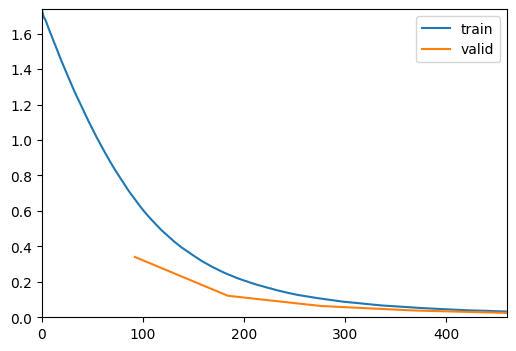

In [ ]:
trainer.fit(max_epochs)

## Check the prediction on the test dataset

              precision    recall  f1-score   support

   AbdomenCT       0.99      1.00      1.00       993
   BreastMRI       1.00      0.99      1.00       903
         CXR       1.00      1.00      1.00       968
     ChestCT       1.00      1.00      1.00       998
        Hand       1.00      1.00      1.00       996
      HeadCT       1.00      1.00      1.00      1037

    accuracy                           1.00      5895
   macro avg       1.00      1.00      1.00      5895
weighted avg       1.00      1.00      1.00      5895


Most Confused Classes:


[('BreastMRI', 'AbdomenCT', np.int64(5)), ('CXR', 'Hand', np.int64(3)), ('HeadCT', 'AbdomenCT', np.int64(3)), ('Hand', 'BreastMRI', np.int64(2)), ('BreastMRI', 'ChestCT', np.int64(1)), ('Hand', 'CXR', np.int64(1)), ('Hand', 'HeadCT', np.int64(1))]


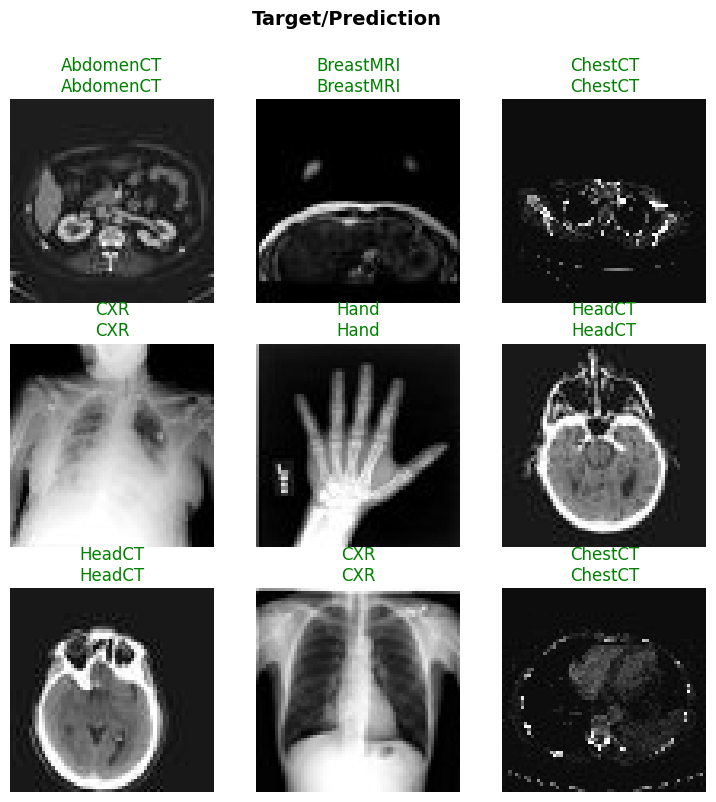

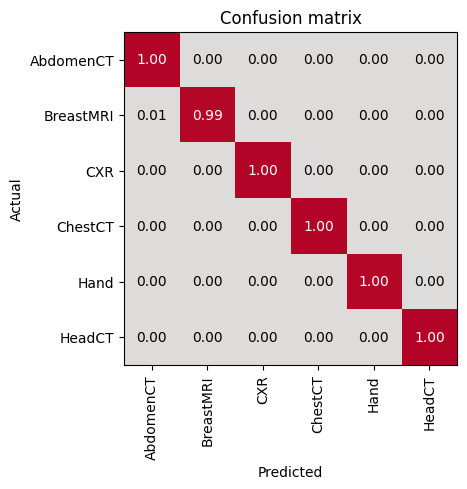

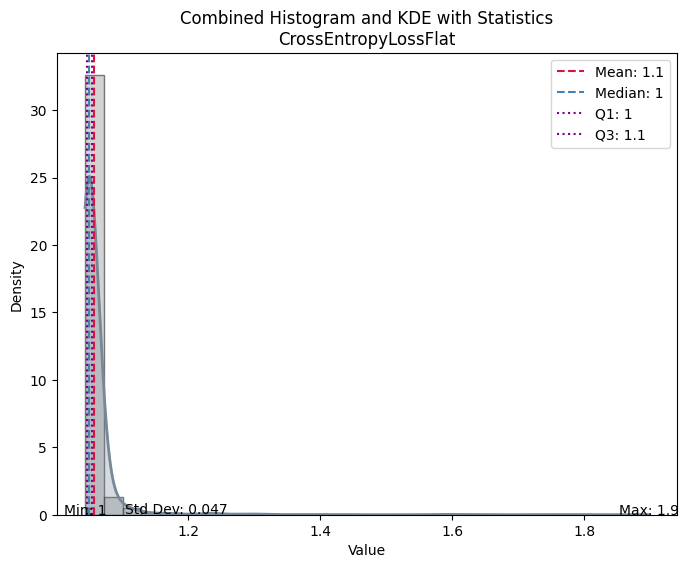

,Value
CrossEntropyLossFlat,
Mean,1.057903
Median,1.049298
Standard Deviation,0.046687
Min,1.043789
Max,1.897614
Q1,1.047298
Q3,1.053827


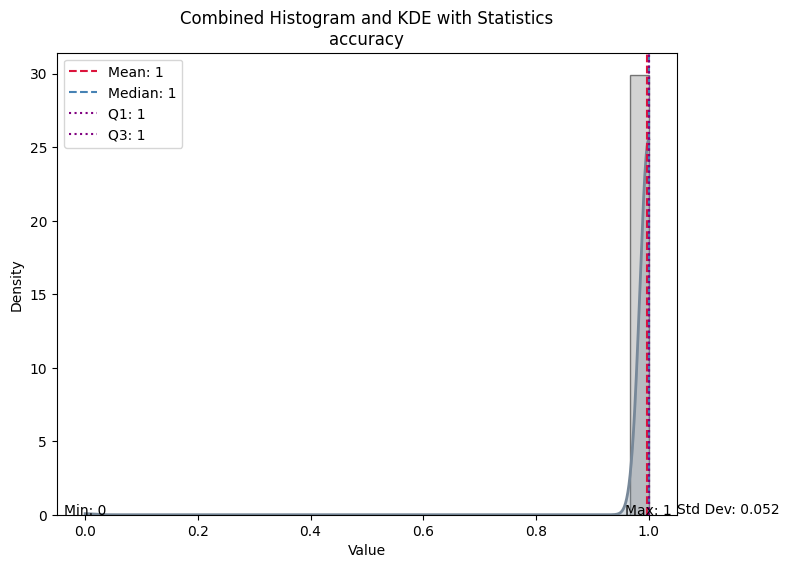

,Value
accuracy,
Mean,0.997286
Median,1.000000
Standard Deviation,0.052027
Min,0.000000
Max,1.000000
Q1,1.000000
Q3,1.000000


In [ ]:
evaluate_classification_model(trainer, test_data, metrics=accuracy, show_graph=True);